In [ ]:
"""Python Initializer Cell"""
#modules and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LinearRegression
%matplotlib inline

#Functions
def get_rmse(line, actual): #function to calculate root mean square error
    error = [(x-y) for x,y in zip(line, actual)]
    errorsquared = [(value)**2 for value in error]
    rmse = np.sqrt(np.mean(errorsquared))
    return(rmse)

def residual_plot(x,y,prediction): #function to generate residuals plot
   residual = y - prediction 
   plt.scatter(x, residual)
   plt.axhline (y=0,color = "r", linestyle = "--")
   plt.show()

#data import
df = pd.read_csv(r"sales_dataset_bydate.csv")

<b><u>Data manipulation in Excel and SQL</b></u> 

The dataset was inspected in Excel for unclean entries using filtering:
- Checked for rogue punctuation marks and non-numeric characters in sale_date column
    - No issues found
- Checked for nonsensical values and non-numeric characters in units_sold column
    - No issues found


The original dataset was not in chronological order and was aggregated to a daily basis. A working copy of sales_dataset.csv was created and named sales_dataset_bydate.csv. It was sorted by date in Excel. 

Table synth_sales was created in PostgreSQL using pgAdmin and the data from sales_dataset_bydate.csv was imported. 

Broke out sales by product category:
```SQL
SELECT product_category, SUM(units_sold) AS total_units
FROM synth_sales
GROUP BY product_category
ORDER BY total_units; 
```

Created monthly time series of sales by product category:
```SQL
SELECT DATE_TRUNC('month', sale_date) AS sales_month, product_category, sum(units_sold) as total_sales
FROM synth_sales
GROUP BY DATE_TRUNC('month', sale_date), product_category
ORDER BY sales_month, product_category;
```

The data from these queries were saved to .CSV files and used to create visualizations in Tableau, and to perform peak-to-trough analysis in Excel. 

<b><u>Data manipulation in Python to prepare for modeling</b></u>

Dates in dataset were strings and needed to be converted to a period object to aggregate data from daily to monthly. This was done using the pandas to_date() function.

Daily sales data was aggregated to monthly using groupby() with the dt accessor, and the monthly total sales column was created using the .agg() function.

To use time as the predictor variable in regression analysis, an ordinal time index was generated using the range() function.

The time index and monthly sales columns were converted into N x 1 column vectors using .reshape().

In [ ]:
df["sale_date"] = pd.to_datetime(df["sale_date"], format = "%m/%d/%Y") #string dates to period object

df_monthly = df.groupby(df["sale_date"].dt.to_period("M")).agg(monthly_sales = ("units_sold", "sum")) #aggregated to monthly, created monthly sales column

df_monthly["time_index"] = list(range(24)) #time index

x = df_monthly["time_index"].values.reshape(-1,1) #N x 1 column vector
y = df_monthly["monthly_sales"].values.reshape(-1,1)

<u><b>Python Analysis</u></b>

To begin with, a linear regression model will be trained and fit to the monthly sales data.

In [5]:
regressor = LinearRegression()
regressor.fit(x,y)

ypred = regressor.predict(x)

The model is plotted against the data.

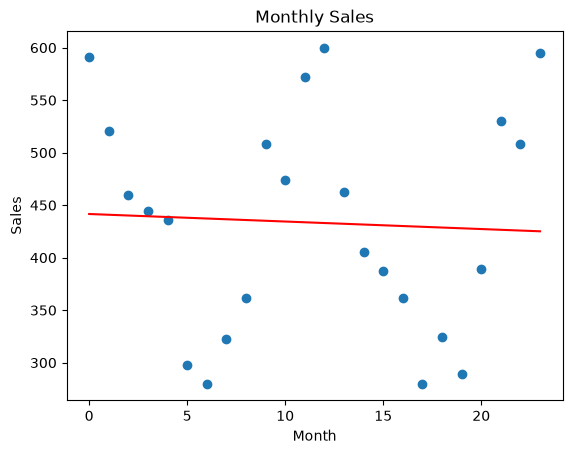

In [6]:
plt.scatter(df_monthly["time_index"], df_monthly["monthly_sales"])
plt.plot(x, ypred, "-r")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

By visual inspection, the model appears to be a poor fit. A residuals plot and RMSE will be used to verify this.

102.94535916998727


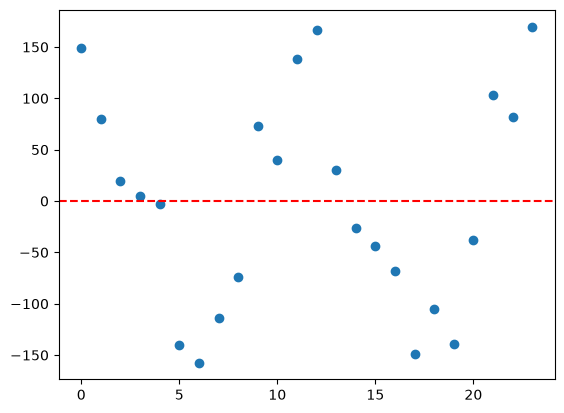

In [7]:
actuals = df_monthly["monthly_sales"].tolist()
print(get_rmse(ypred,actuals))

residual_plot(x,y,ypred)

The residuals plot appears non-random, and is identical to the data, indicating that the model systematically fails to fit the data. 
Since the data appears seasonal, we will try trigonometric regression instead. 

We will perform sine and cosine transformations:

sin⁡(x ∗ 2π/12),  cos(x ∗ 2π/12)

In [9]:
df_monthly["sin_period"] = df_monthly["time_index"].apply(lambda x: math.sin(x * 2 * math.pi / 12))
df_monthly["cos_period"] = df_monthly["time_index"].apply(lambda x: math.cos(x * 2 * math.pi / 12))
x_trig = df_monthly.loc[:,["time_index","sin_period","cos_period"]].values.reshape(-1,3)

The new model is trained.

In [10]:
trig_regressor = LinearRegression()
trig_regressor.fit(x_trig, y)

ypred_trig = trig_regressor.predict(x_trig)

The new model is plotted against the data.

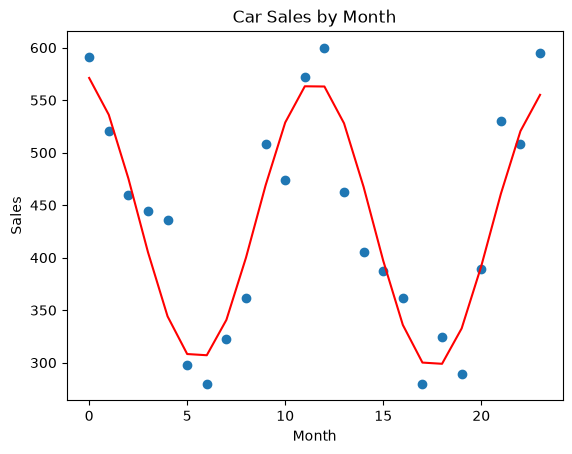

In [19]:
plt.scatter(df_monthly["time_index"], df_monthly["monthly_sales"])
plt.plot(x, ypred_trig,"r-")
plt.title("Car Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Residuals plot and RMSE are generated to check the fit of the model.

39.65929113008817


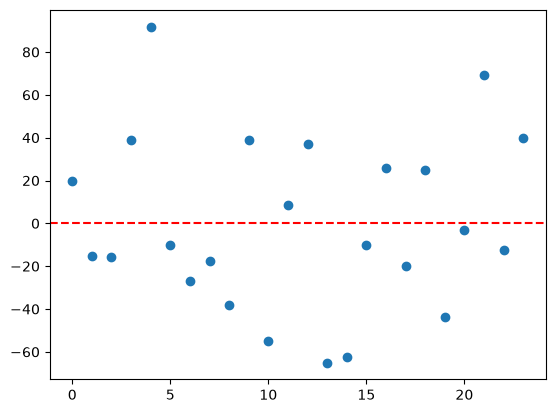

In [12]:
print(get_rmse(ypred_trig,actuals))

residual_plot(x,y,ypred_trig)

Residuals plot appears close to random, and RMSE is much improved (39.65 for trig, vs 102.94 for linear), suggesting a much better fit and supporting the view that the data follows a seasonal structure.